In [3]:
import pandas as pd

df = pd.read_csv("College.csv")
df.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [4]:
df["Private"] = (df["Private"] == "Yes").astype(int)

In [5]:
df["Interaccion"]=df["Outstate"]*df["perc.alumni"]

In [6]:
df.columns

Index(['Unnamed: 0', 'Private', 'Apps', 'Accept', 'Enroll', 'Top10perc',
       'Top25perc', 'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board',
       'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni',
       'Expend', 'Grad.Rate', 'Interaccion'],
      dtype='str')

In [7]:
import statsmodels.api as sm
columnas = ['Private', 'Apps', 'Accept', 'Enroll', 'Top10perc',
       'Top25perc', 'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board',
       'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni',
       'Expend', 'Interaccion']
X = df[columnas]
Y = df["Grad.Rate"]
# falta agregar columna de unos
X = sm.add_constant(X)
ols = sm.OLS(Y, X)
results = ols.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Grad.Rate   R-squared:                       0.462
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     36.11
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           2.95e-89
Time:                        13:10:23   Log-Likelihood:                -3070.9
No. Observations:                 777   AIC:                             6180.
Df Residuals:                     758   BIC:                             6268.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          34.7226      5.429      6.396      0.000      24.065      45.380
Private         3.5478      1.763      2.012      0.045       0.086       7.010
Apps            0.0013      0.000      2.876      0.004       0.000       0.002
Accept         -0.0007      0.001     -0.753      0.452      -0.002       0.001
Enroll          0.0022      0.002      0.936      0.349      -0.002       0.007
Top10perc       0.0532      0.072      0.739      0.460      -0.088       0.194
Top25perc       0.1359      0.055      2.469      0.014       0.028       0.244
F.Undergrad    -0.0005      0.000     -1.165      0.244      -0.001       0.000
P.Undergrad    -0.0015      0.000     -3.808      0.000      -0.002      -0.001
Outstate        0.0009      0.000      2.647      0.008       0.000       0.002
Room.Board      0.0019      0.001      3.257      0.001       0.001       0.003
Books          -0.0022      0.003     -0.753      0.452      -0.008       0.004
Personal       -0.0017      0.001     -2.152      0.032      -0.003      -0.000
PhD             0.0873      0.057      1.536      0.125      -0.024       0.199
Terminal       -0.0747      0.062     -1.198      0.231      -0.197       0.048
S.F.Ratio       0.0672      0.161      0.417      0.677      -0.249       0.384
perc.alumni     0.2420      0.118      2.050      0.041       0.010       0.474
Expend         -0.0005      0.000     -2.972      0.003      -0.001      -0.000
Interaccion  3.342e-06    9.6e-06      0.348      0.728   -1.55e-05    2.22e-05
==============================================================================
Omnibus:                       35.910   Durbin-Watson:                   2.004
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               95.187
Skew:                           0.165   Prob(JB):                     2.14e-21
Kurtosis:                       4.683   Cond. No.                     4.12e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.12e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [8]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X, Y)
y_pred = lr.predict(X)
residuos_y = Y - y_pred

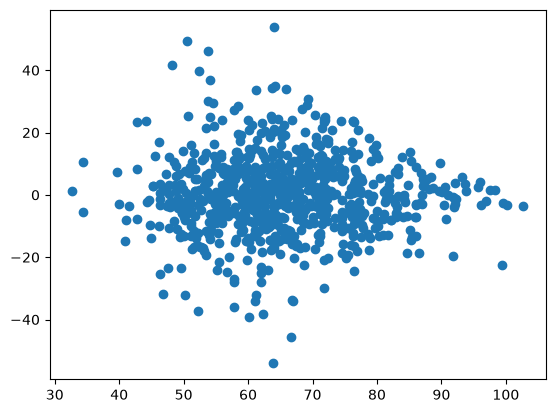

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_pred, residuos_y)

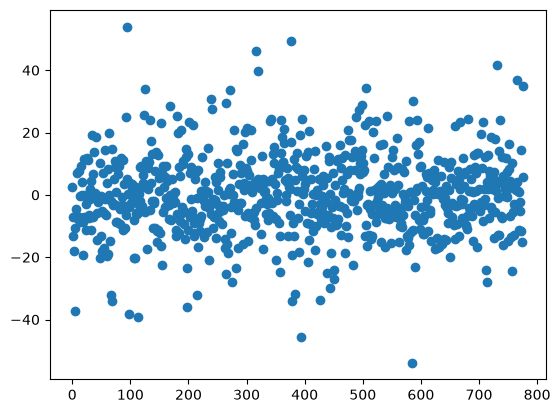

In [10]:
plt.figure()
plt.scatter(range(len(residuos_y.values)),residuos_y.values)

In [11]:
import numpy as np

X_mat = X.values
n, p = X_mat.shape

H = X_mat @ np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T
leverage = np.diag(H)

rse = np.sqrt(np.sum(residuos_y**2) / (n - p))
resid_student = residuos_y / (rse * np.sqrt(1 - leverage))

Text(0, 0.5, 'Residuos estudentizados')

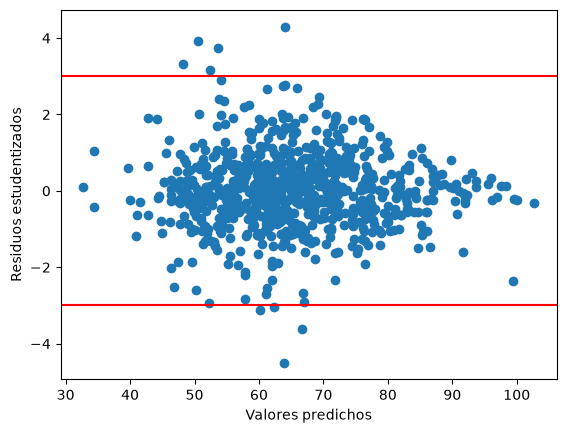

In [12]:
plt.figure()
plt.scatter(y_pred, resid_student)
plt.axhline(3, color="red")
plt.axhline(-3, color="red")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos estudentizados")

Text(0, 0.5, 'Residuos estudentizados')

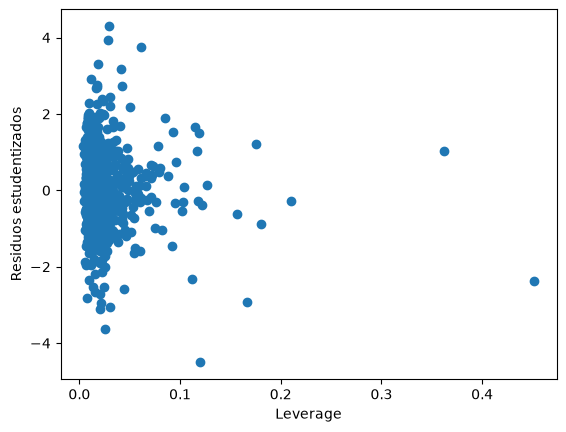

In [13]:
plt.figure()
plt.scatter(leverage, resid_student)
plt.xlabel("Leverage")
plt.ylabel("Residuos estudentizados")

In [14]:
for col in columnas:
    otras = columnas.copy()
    otras.remove(col)
    X_aux = df[otras]
    X_aux = sm.add_constant(X_aux)
    y_aux = df[col]
    r2_aux = sm.OLS(y_aux, X_aux).fit().rsquared
    vif = 1 / (1 - r2_aux)
    print(col, vif)

Private 2.947635491643335
Apps 14.159762719773632
Accept 21.7513751403085
Enroll 21.97174667649819
Top10perc 7.690570400390198
Top25perc 5.669769885085679
F.Undergrad 18.07058909487074
P.Undergrad 1.6867381672915258
Outstate 9.461258906954784
Room.Board 2.0341747408052115
Books 1.108408092921778
Personal 1.2982056623229026
PhD 4.110407620699486
Terminal 4.020952129482717
S.F.Ratio 1.945221346964259
perc.alumni 10.203652921018058
Expend 3.210127684897949
Interaccion 21.61711746233591
